In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

DATA = Path("../data/eicu-demo")
patients = pd.read_csv(DATA / "patient.csv.gz")
print(patients.shape)
patients.head()


Matplotlib is building the font cache; this may take a moment.


(2520, 29)


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
0,141764,129391,Female,87,Caucasian,59,91,NaN,157.5,23:36:00,...,ICU to SDU,2,stepdown/other,NaN,NaN,18:58:00,344,Home,Alive,002-1039
1,141765,129391,Female,87,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,Emergency Department,1,admit,46.5,45.0,13:14:00,2250,Step-Down Unit (SDU),Alive,002-1039
2,143870,131022,Male,76,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,Operating Room,1,admit,77.5,79.4,10:00:00,793,Floor,Alive,002-12289
3,144815,131736,Female,34,Caucasian,56,82,"Overdose, other toxin, poison or drug",172.7,01:44:00,...,Emergency Department,1,admit,60.3,60.7,20:48:00,1121,Other External,Alive,002-1116
4,145427,132209,Male,61,Caucasian,68,103,"GI perforation/rupture, surgery for",177.8,23:48:00,...,Operating Room,1,admit,91.7,93.1,22:47:00,1369,Floor,Alive,002-12243


ICU stay: median 35.1 h, spread 1.05  (n = 2453)


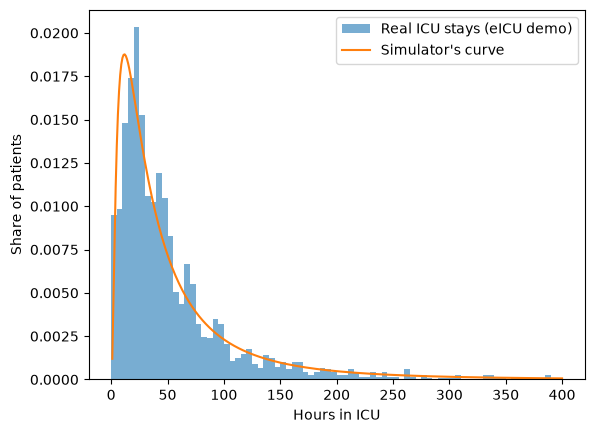

In [2]:
icu_hours = patients["unitdischargeoffset"] / 60
icu_hours = icu_hours[(icu_hours > 1) & (icu_hours < 60 * 24)]
log_hours = np.log(icu_hours)
icu_median, icu_spread = np.exp(log_hours.mean()), log_hours.std()
print(f"ICU stay: median {icu_median:.1f} h, spread {icu_spread:.2f}  (n = {len(icu_hours)})")

x = np.linspace(1, 400, 400)
plt.hist(icu_hours, bins=80, range=(0, 400), density=True, alpha=0.6, label="Real ICU stays (eICU demo)")
plt.plot(x, stats.lognorm(s=icu_spread, scale=icu_median).pdf(x), label="Simulator's curve")
plt.xlabel("Hours in ICU")
plt.ylabel("Share of patients")
plt.legend()
plt.show()


In [3]:
print("How ICU stays ended:")
print(patients["unitdischargestatus"].value_counts(normalize=True).round(3))

print("\nWhere the survivors went:")
alive = patients["unitdischargestatus"] == "Alive"
print(patients.loc[alive, "unitdischargelocation"].value_counts(normalize=True).round(3))


How ICU stays ended:
unitdischargestatus
Alive      0.95
Expired    0.05
Name: proportion, dtype: float64

Where the survivors went:
unitdischargelocation
Floor                       0.497
Home                        0.136
Step-Down Unit (SDU)        0.102
Acute Care/Floor            0.090
Telemetry                   0.062
Other Hospital              0.040
Other ICU                   0.022
Other External              0.013
Skilled Nursing Facility    0.013
Other                       0.009
ICU                         0.006
Rehabilitation              0.004
Nursing Home                0.004
Other Internal              0.001
Name: proportion, dtype: float64


In [4]:
survived = patients["hospitaldischargestatus"] == "Alive"
ward_hours = (patients["hospitaldischargeoffset"] - patients["unitdischargeoffset"]) / 60
ward_hours = ward_hours[survived & (ward_hours > 1) & (ward_hours < 60 * 24)]
log_ward = np.log(ward_hours)
ward_median, ward_spread = np.exp(log_ward.mean()), log_ward.std()
print(f"Ward stay after ICU: median {ward_median:.1f} h, spread {ward_spread:.2f}  (n = {len(ward_hours)})")


Ward stay after ICU: median 59.9 h, spread 1.11  (n = 1754)


Where ICU patients came from:
unitadmitsource
Emergency Department    0.522
Floor                   0.132
Operating Room          0.101
ICU to SDU              0.059
Direct Admit            0.056
Recovery Room           0.030
Name: proportion, dtype: float64


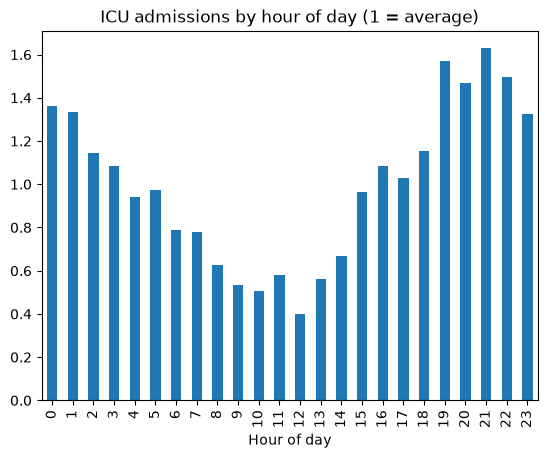

In [5]:
print("Where ICU patients came from:")
print(patients["unitadmitsource"].value_counts(normalize=True).round(3).head(6))

hours = pd.to_datetime(patients["unitadmittime24"], format="%H:%M:%S").dt.hour
pattern = hours.value_counts().sort_index()
pattern = pattern / pattern.mean()
pattern.plot(kind="bar", title="ICU admissions by hour of day (1 = average)")
plt.xlabel("Hour of day")
plt.show()
